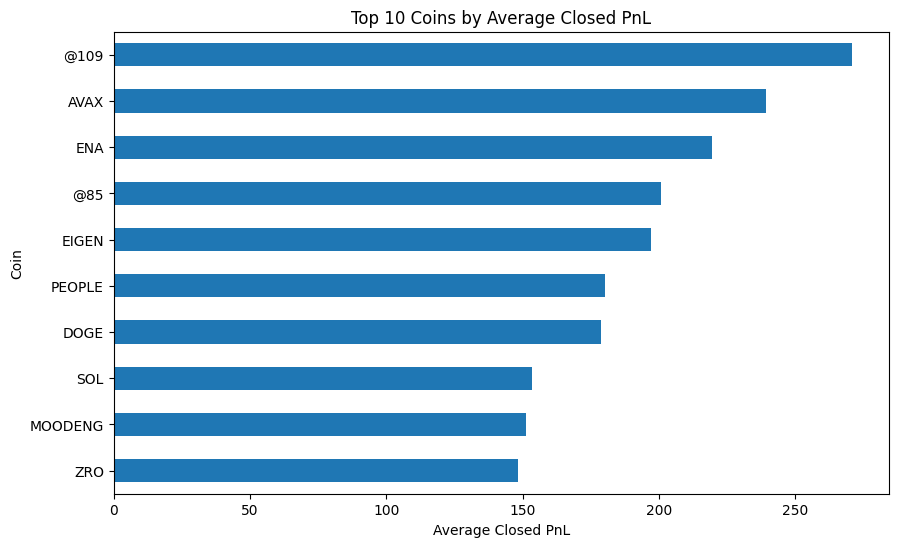

In [96]:
top_coins = (
    merged_df.groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_coins.sort_values().plot(kind="barh")

plt.title("Top 10 Coins by Average Closed PnL")
plt.xlabel("Average Closed PnL")
plt.ylabel("Coin")

plt.show()

# This visualization highlights the coins that generated the highest average profit, providing insight into which assets performed best over the observed period.

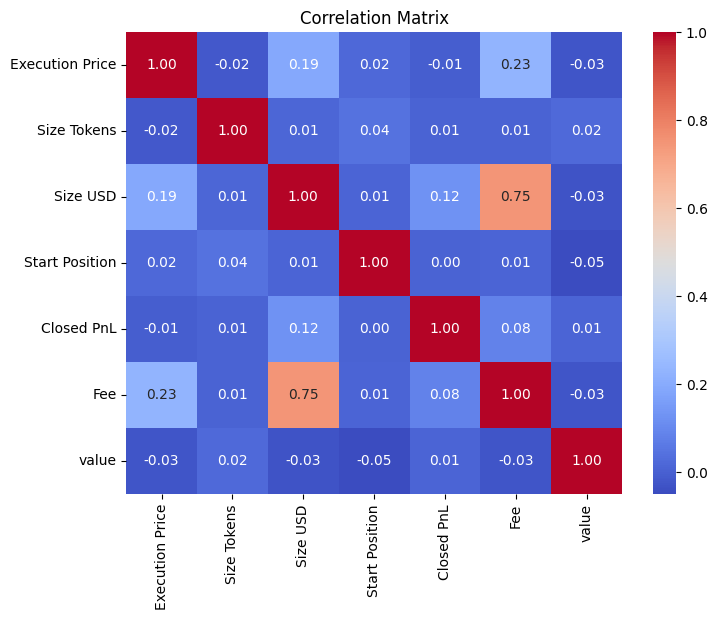

In [95]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee',
    'value'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    merged_df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# The heatmap reveals linear relationships among numerical variables, helping identify which trading metrics are most closely associated with profitability.

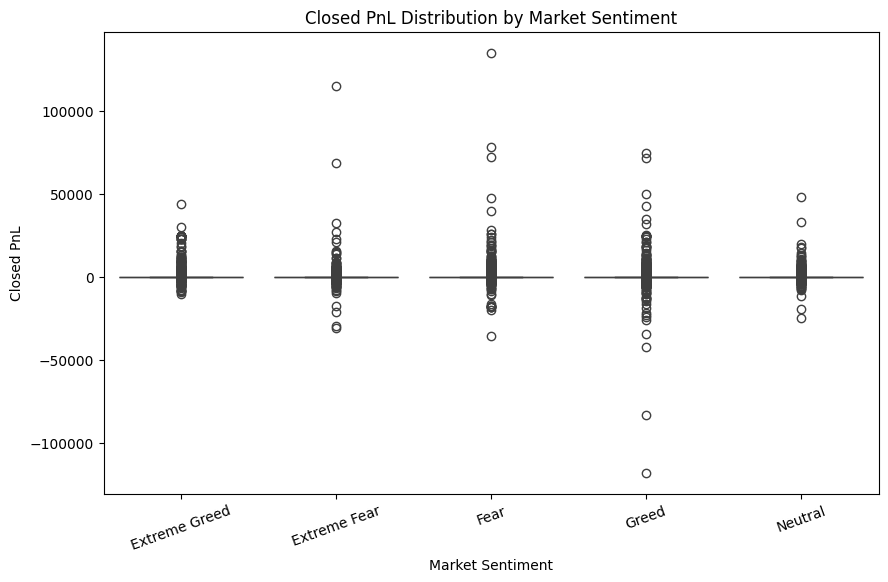

In [94]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=20)

plt.show()

# The box plot highlights the variability and spread of trader profits across different market sentiment categories. It also reveals outliers, indicating that some trades generate exceptionally high profits or losses.

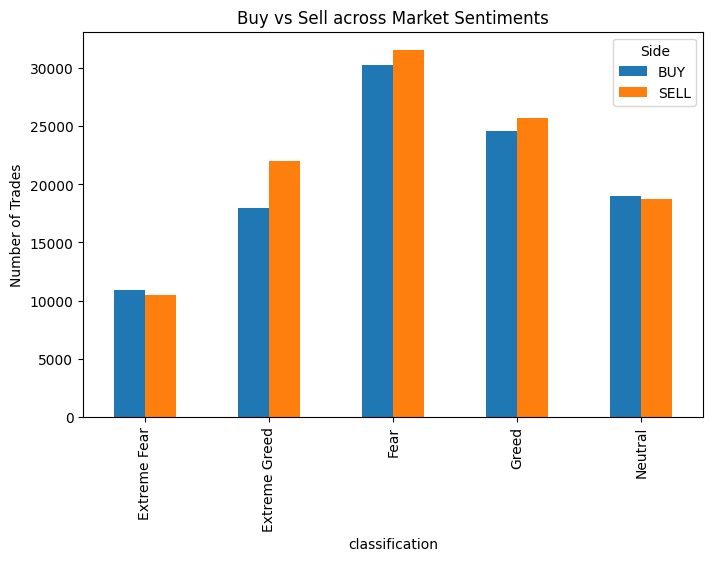

In [93]:
buy_sell = pd.crosstab(
    merged_df["classification"],
    merged_df["Side"]
)

buy_sell

buy_sell.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Buy vs Sell across Market Sentiments")
plt.ylabel("Number of Trades")

plt.show()

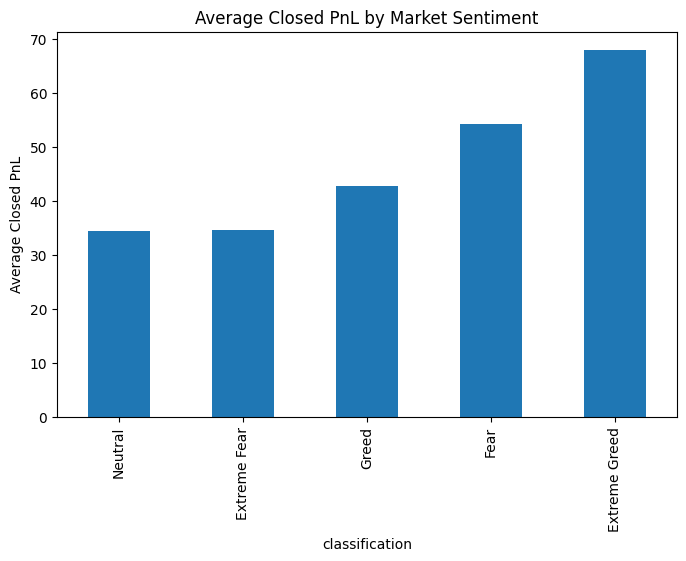

In [92]:
avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean().sort_values()

avg_pnl

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

# Average Closed PnL by Market Sentiment

This analysis compares the average profit or loss generated by traders under different market sentiment conditions.

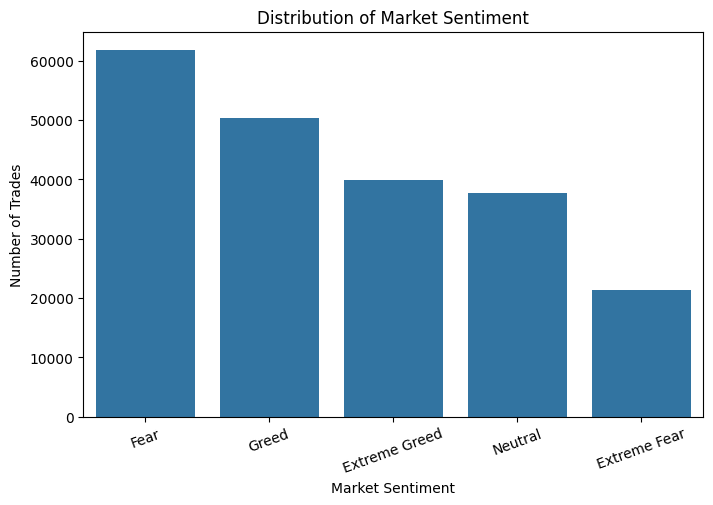

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)

plt.show()

## Exploratory Data Analysis (EDA)

# Distribution of Market Sentiment

This visualization shows the frequency of different market sentiment categories in the dataset.

In [90]:
print("Merged Dataset Shape:", merged_df.shape)

merged_df.head()

Merged Dataset Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [89]:
merged_df = pd.merge(
    trades,
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

In [88]:
sentiment[['date','Date','classification','value']].head()

,date,Date,classification,value
0,2018-02-01,2018-02-01,Fear,30
1,2018-02-02,2018-02-02,Extreme Fear,15
2,2018-02-03,2018-02-03,Fear,40
3,2018-02-04,2018-02-04,Extreme Fear,24
4,2018-02-05,2018-02-05,Extreme Fear,11


In [87]:
trades[['Timestamp IST','Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [86]:
# Convert trader timestamp (day-first format)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

# Extract only the date
trades['Date'] = trades['Timestamp IST'].dt.date

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

## Data Preprocessing

In [85]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
print("Historical Data Duplicates:", trades.duplicated().sum())
print("Fear & Greed Duplicates:", sentiment.duplicated().sum())

Historical Data Duplicates: 0
Fear & Greed Duplicates: 0


In [84]:
print("Missing Values in Historical Data")
display(trades.isnull().sum())

print("\nMissing Values in Fear & Greed Data")
display(sentiment.isnull().sum())

Missing Values in Historical Data


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Missing Values in Fear & Greed Data


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [ ]:
print("===== Historical Trader Data =====")
trades.info()

print("\n===== Fear & Greed Data =====")
sentiment.info()

===== Historical Trader Data =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224

In [83]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [82]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Preview the Datasets

In [81]:
trades = pd.read_csv("Data/historical_data.csv")
sentiment = pd.read_csv("Data/fear_greed_index.csv")

print("Historical Trader Data:", trades.shape)
print("Fear & Greed Data:", sentiment.shape)

Historical Trader Data: (211224, 16)
Fear & Greed Data: (2644, 4)


## Load the Datasets

In [80]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better chart size
plt.rcParams['figure.figsize'] = (10,6)